In [11]:
# 2. 创建回归版本的高尔夫数据集

import platform
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

def set_chinese_font():
    system = platform.system()
    if system == 'Windows':
        plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
    elif system == 'Darwin':  # macOS
        plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS']
    else:  # Linux
        plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

set_chinese_font() 

# 创建回归版高尔夫数据集
data = pd.DataFrame({
    '天气': ['晴天', '晴天', '阴天', '雨天', '雨天', '雨天', '阴天', '晴天', 
            '晴天', '雨天', '晴天', '阴天', '阴天', '雨天'],
    '温度': ['高', '高', '高', '适中', '冷', '冷', '冷', '适中', 
            '冷', '适中', '适中', '适中', '高', '适中'],
    '湿度': ['高', '高', '高', '高', '正常', '正常', '正常', '高', 
            '正常', '正常', '正常', '高', '正常', '高'],
    '刮风': ['否', '是', '否', '否', '否', '是', '是', '否', 
            '否', '否', '是', '是', '否', '是'],
    '打球人数': [8, 5, 15, 12, 18, 6, 20, 7, 
               19, 14, 16, 22, 21, 9]  # 连续数值：打球人数
})

print("回归版高尔夫数据集：")
print(data)
print(f"\n打球人数统计: 均值={data['打球人数'].mean():.1f}, "
      f"标准差={data['打球人数'].std():.1f}, "
      f"范围=[{data['打球人数'].min()}, {data['打球人数'].max()}]")


回归版高尔夫数据集：
    天气  温度  湿度 刮风  打球人数
0   晴天   高   高  否     8
1   晴天   高   高  是     5
2   阴天   高   高  否    15
3   雨天  适中   高  否    12
4   雨天   冷  正常  否    18
5   雨天   冷  正常  是     6
6   阴天   冷  正常  是    20
7   晴天  适中   高  否     7
8   晴天   冷  正常  否    19
9   雨天  适中  正常  否    14
10  晴天  适中  正常  是    16
11  阴天  适中   高  是    22
12  阴天   高  正常  否    21
13  雨天  适中   高  是     9

打球人数统计: 均值=13.7, 标准差=5.9, 范围=[5, 22]


In [5]:
# 3. 编码特征
from sklearn.preprocessing import LabelEncoder

# 编码分类变量
le_weather = LabelEncoder()
le_temp = LabelEncoder()
le_humidity = LabelEncoder()
le_wind = LabelEncoder()

data['天气编码'] = le_weather.fit_transform(data['天气'])
data['温度编码'] = le_temp.fit_transform(data['温度'])
data['湿度编码'] = le_humidity.fit_transform(data['湿度'])
data['刮风编码'] = le_wind.fit_transform(data['刮风'])

print("\n编码映射：")
print(f"天气: {dict(zip(le_weather.classes_, range(len(le_weather.classes_))))}")
print(f"温度: {dict(zip(le_temp.classes_, range(len(le_temp.classes_))))}")
print(f"湿度: {dict(zip(le_humidity.classes_, range(len(le_humidity.classes_))))}")
print(f"刮风: {dict(zip(le_wind.classes_, range(len(le_wind.classes_))))}")

# 特征和标签
feature_cols = ['天气编码', '温度编码', '湿度编码', '刮风编码']
feature_names = ['天气', '温度', '湿度', '刮风']
X = data[feature_cols].values
y = data['打球人数'].values  # 连续数值！


编码映射：
天气: {'晴天': 0, '阴天': 1, '雨天': 2}
温度: {'冷': 0, '适中': 1, '高': 2}
湿度: {'正常': 0, '高': 1}
刮风: {'否': 0, '是': 1}


In [8]:
# 4. PIPPER算法实现

class PIPPERRegressor:
    """
    PIPPER算法回归版本
    核心思想：学习IF-THEN规则来预测连续数值
    """
    
    def __init__(self, min_samples_split=2, max_depth=3, pruning_ratio=0.3):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.pruning_ratio = pruning_ratio
        self.rules = []  # 存储规则列表
        self.default_value = None  # 默认预测值
        
    def variance(self, y):
        """计算方差（回归任务的纯度指标）[citation:3][citation:5]"""
        if len(y) == 0:
            return 0
        return np.var(y)
    
    def mse(self, y_true, y_pred):
        """均方误差"""
        return np.mean((y_true - y_pred) ** 2)
    
    def weighted_variance(self, y_left, y_right):
        """计算加权方差（分裂后的不纯度）[citation:3]"""
        n_total = len(y_left) + len(y_right)
        if n_total == 0:
            return 0
        var_left = self.variance(y_left) * (len(y_left) / n_total)
        var_right = self.variance(y_right) * (len(y_right) / n_total)
        return var_left + var_right
    
    def variance_reduction(self, y_parent, y_left, y_right):
        """计算方差减少量（类似信息增益）[citation:3]"""
        var_parent = self.variance(y_parent)
        var_child = self.weighted_variance(y_left, y_right)
        return var_parent - var_child
    
    def find_best_split(self, X, y, feature_values_map=None):
        """
        找到最佳的特征和分裂值
        对于分类特征：特征值相等 vs 不等
        对于数值特征：<=阈值 vs >阈值
        """
        best_gain = -1
        best_feature_idx = None
        best_split_value = None
        best_left_mask = None
        best_right_mask = None
        
        n_samples, n_features = X.shape
        
        for feature_idx in range(n_features):
            feature_values = X[:, feature_idx]
            unique_values = np.unique(feature_values)
            
            # 对每个特征值作为分裂点
            for split_val in unique_values:
                # 分裂：特征值 == split_val vs 特征值 != split_val
                left_mask = (feature_values == split_val)
                right_mask = ~left_mask
                
                if sum(left_mask) < self.min_samples_split or sum(right_mask) < self.min_samples_split:
                    continue
            
                y_left = y[left_mask]
                y_right = y[right_mask]
                
                gain = self.variance_reduction(y, y_left, y_right)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature_idx = feature_idx
                    best_split_value = split_val
                    best_left_mask = left_mask.copy()
                    best_right_mask = right_mask.copy()
        
        return best_feature_idx, best_split_value, best_left_mask, best_right_mask, best_gain
    

    def learn_rules(self, X, y, feature_names, depth=0, conditions=None):
        """递归学习规则（类似决策树构建）"""
        if conditions is None:
            conditions = []
        
        # 停止条件
        if len(y) < self.min_samples_split or depth >= self.max_depth:
            # 叶节点：保存规则
            prediction = np.mean(y)  # 均值作为预测值[citation:3][citation:5]
            rule = {
                'conditions': conditions.copy(),
                'prediction': prediction,
                'samples': len(y),
                'variance': self.variance(y)
            }
            self.rules.append(rule)
            return
        
        # 寻找最佳分裂
        feat_idx, split_val, left_mask, right_mask, gain = self.find_best_split(X, y)
        
        if feat_idx is None or gain <= 0:
            # 无法继续分裂
            prediction = np.mean(y)
            rule = {
                'conditions': conditions.copy(),
                'prediction': prediction,
                'samples': len(y),
                'variance': self.variance(y)
            }
            self.rules.append(rule)
            return
        
        # 解码特征名
        feature = feature_names[feat_idx]
        feature_value = self._decode_feature_value(feature, split_val)
        
        # 左分支：特征 == 特定值
        left_conditions = conditions + [f"{feature} == {feature_value}"]
        X_left = X[left_mask]
        y_left = y[left_mask]
        
        # 右分支：特征 != 特定值 
        right_conditions = conditions + [f"{feature} != {feature_value}"]
        X_right = X[right_mask]
        y_right = y[right_mask]
        
        # 递归学习
        if len(X_left) > 0:
            self.learn_rules(X_left, y_left, feature_names, depth + 1, left_conditions)
        if len(X_right) > 0:
            self.learn_rules(X_right, y_right, feature_names, depth + 1, right_conditions)

    def _decode_feature_value(self, feature, encoded_value):
        """将编码值解码为原始值"""
        if feature == '天气':
            return le_weather.inverse_transform([int(encoded_value)])[0]
        elif feature == '温度':
            return le_temp.inverse_transform([int(encoded_value)])[0]
        elif feature == '湿度':
            return le_humidity.inverse_transform([int(encoded_value)])[0]
        elif feature == '刮风':
            return le_wind.inverse_transform([int(encoded_value)])[0]
        return str(encoded_value)   

    def prune_rules(self, X_val, y_val):
        """
        后剪枝：移除在验证集上表现差的规则
        """
        if len(self.rules) == 0:
            return
        
        # 计算每条规则在验证集上的表现
        rule_errors = []
        for rule in self.rules:
            error = self._evaluate_rule_on_validation(rule, X_val, y_val)
            rule_errors.append(error)
        
        # 按误差排序，剪枝效果最差的
        n_prune = int(len(self.rules) * self.pruning_ratio)
        if n_prune > 0:
            # 保留前(1-pruning_ratio)条规则
            sorted_indices = np.argsort(rule_errors)
            keep_indices = sorted_indices[:len(self.rules) - n_prune]
            self.rules = [self.rules[i] for i in keep_indices]
            
    def _evaluate_rule_on_validation(self, rule, X_val, y_val):
        """评估规则在验证集上的MSE"""
        # 找到匹配该规则的样本
        matches = self._find_matches(rule['conditions'], X_val)
        if np.sum(matches) == 0:
            return float('inf')
        
        y_matched = y_val[matches]
        predictions = np.full(len(y_matched), rule['prediction'])
        return self.mse(y_matched, predictions)

    def _find_matches(self, conditions, X):
        """找到匹配规则条件的样本"""
        matches = np.ones(len(X), dtype=bool)
        
        for condition in conditions:
            # 解析条件: "天气 == 晴天" 或 "天气 != 晴天"
            if '==' in condition:
                attr, value = condition.split(' == ')
                col_idx = self._get_feature_index(attr)
                encoded_value = self._encode_feature_value(attr, value)
                matches &= (X[:, col_idx] == encoded_value)
            elif '!=' in condition:
                attr, value = condition.split(' != ')
                col_idx = self._get_feature_index(attr)
                encoded_value = self._encode_feature_value(attr, value)
                matches &= (X[:, col_idx] != encoded_value)
        
        return matches


    def _get_feature_index(self, feature_name):
        """获取特征索引"""
        mapping = {'天气': 0, '温度': 1, '湿度': 2, '刮风': 3}
        return mapping.get(feature_name, 0)

    def _encode_feature_value(self, feature, value):
        """将原始特征值编码"""
        if feature == '天气':
            return le_weather.transform([value])[0]
        elif feature == '温度':
            return le_temp.transform([value])[0]
        elif feature == '湿度':
            return le_humidity.transform([value])[0]
        elif feature == '刮风':
            return le_wind.transform([value])[0]
        return value

    def fit(self, X, y, feature_names, X_val=None, y_val=None):
        """训练模型"""
        # 1. 设置默认值（所有样本的均值）
        self.default_value = np.mean(y)
        
        # 2. 学习规则
        self.learn_rules(X, y, feature_names)
        
        # 3. 剪枝（如果提供验证集）
        if X_val is not None and y_val is not None:
            self.prune_rules(X_val, y_val)
        
        print(f"学习到 {len(self.rules)} 条规则")
        return self

    def predict(self, X):
        """预测新样本"""
        predictions = []
        
        for sample in X:
            predicted = None
            
            # 按规则顺序匹配
            for rule in self.rules:
                matches = self._find_matches(rule['conditions'], sample.reshape(1, -1))
                if matches[0]:  # 匹配成功
                    predicted = rule['prediction']
                    break
            
            # 没有匹配的规则，使用默认值[citation:1]
            if predicted is None:
                predicted = self.default_value
                
            predictions.append(predicted)
        
        return np.array(predictions)

    def print_rules(self):
        """打印所有规则"""
        print("\n" + "="*60)
        print("PIPPER回归规则集")
        print("="*60)
        
        for i, rule in enumerate(self.rules, 1):
            conditions = " AND ".join(rule['conditions'])
            print(f"规则{i}: IF {conditions}")
            print(f"        THEN 预测打球人数 = {rule['prediction']:.1f} 人")
            print(f"        (覆盖 {rule['samples']} 个样本, 方差={rule['variance']:.2f})")
        
        print(f"\n默认规则: ELSE 预测打球人数 = {self.default_value:.1f} 人")


In [9]:
# 5. train and evaluate 

# 分割数据集（70%训练，30%测试）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 从训练集中划分验证集用于剪枝（训练集的20%）
split_idx = int(len(X_train) * 0.8)
X_train_main, X_val = X_train[:split_idx], X_train[split_idx:]
y_train_main, y_val = y_train[:split_idx], y_train[split_idx:]

print(f"训练集: {len(X_train_main)} 样本")
print(f"验证集: {len(X_val)} 样本")
print(f"测试集: {len(X_test)} 样本")

# 创建PIPPER回归模型
pipper = PIPPERRegressor(
    min_samples_split=2,
    max_depth=3,
    pruning_ratio=0.2  # 剪枝20%的规则
)

# 训练
pipper.fit(X_train_main, y_train_main, feature_names, X_val, y_val)

# 打印规则
pipper.print_rules()

# 预测
y_pred_train = pipper.predict(X_train_main)
y_pred_test = pipper.predict(X_test)

# 评估
print("\n" + "="*60)
print("模型评估结果")
print("="*60)

train_mse = mean_squared_error(y_train_main, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_r2 = r2_score(y_train_main, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print(f"训练集 MSE: {train_mse:.2f}, R²: {train_r2:.3f}")
print(f"测试集 MSE: {test_mse:.2f}, R²: {test_r2:.3f}")

# 对比基线模型（简单均值预测）
baseline_pred = np.full(len(y_test), np.mean(y_train_main))
baseline_mse = mean_squared_error(y_test, baseline_pred)
print(f"\n基线模型（均值预测）MSE: {baseline_mse:.2f}")
print(f"PIPPER改进: {(baseline_mse - test_mse) / baseline_mse * 100:.1f}%")

训练集: 7 样本
验证集: 2 样本
测试集: 5 样本
学习到 3 条规则

PIPPER回归规则集
规则1: IF 湿度 == 正常
        THEN 预测打球人数 = 17.7 人
        (覆盖 3 个样本, 方差=1.56)
规则2: IF 湿度 != 正常 AND 天气 == 晴天
        THEN 预测打球人数 = 6.0 人
        (覆盖 2 个样本, 方差=1.00)
规则3: IF 湿度 != 正常 AND 天气 != 晴天
        THEN 预测打球人数 = 12.0 人
        (覆盖 2 个样本, 方差=9.00)

默认规则: ELSE 预测打球人数 = 12.7 人

模型评估结果
训练集 MSE: 3.52, R²: 0.870
测试集 MSE: 52.93, R²: -0.244

基线模型（均值预测）MSE: 44.77
PIPPER改进: -18.2%


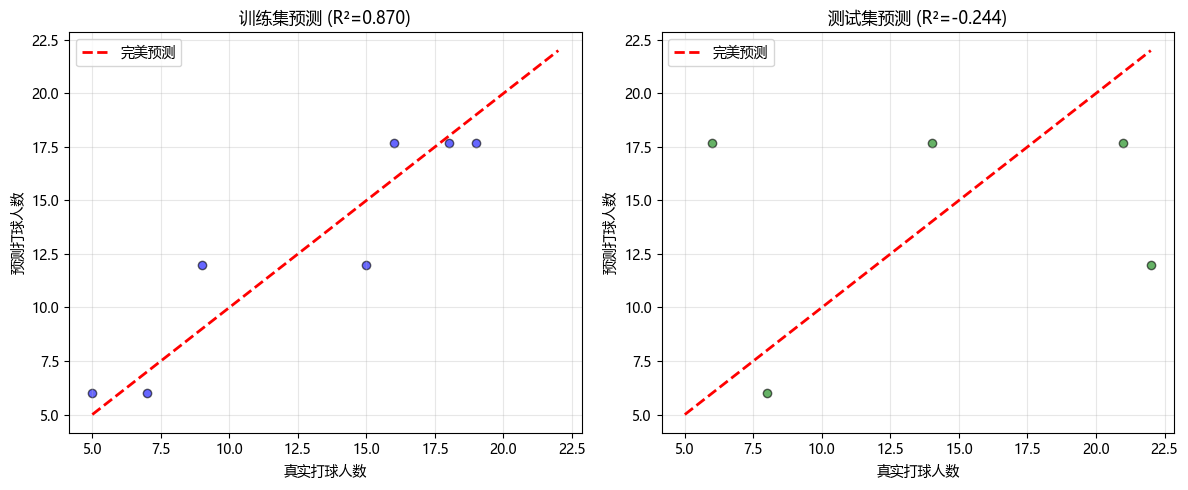

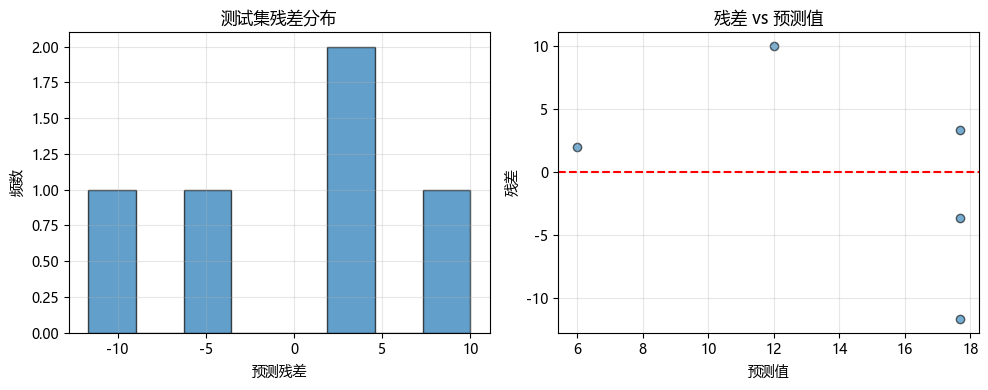

In [12]:
# 预测值与真实值对比
plt.figure(figsize=(12, 5))

# 子图1：训练集对比
plt.subplot(1, 2, 1)
plt.scatter(y_train_main, y_pred_train, alpha=0.6, c='blue', edgecolors='k')
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--', lw=2, label='完美预测')
plt.xlabel('真实打球人数')
plt.ylabel('预测打球人数')
plt.title(f'训练集预测 (R²={train_r2:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2：测试集对比
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, alpha=0.6, c='green', edgecolors='k')
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--', lw=2, label='完美预测')
plt.xlabel('真实打球人数')
plt.ylabel('预测打球人数')
plt.title(f'测试集预测 (R²={test_r2:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 残差分析
residuals = y_test - y_pred_test
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(residuals, bins=8, edgecolor='black', alpha=0.7)
plt.xlabel('预测残差')
plt.ylabel('频数')
plt.title('测试集残差分布')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_pred_test, residuals, alpha=0.6, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('预测值')
plt.ylabel('残差')
plt.title('残差 vs 预测值')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.tree import DecisionTreeRegressor

# 标准决策树回归
dt_regressor = DecisionTreeRegressor(
    max_depth=3,
    min_samples_split=2,
    random_state=42
)
dt_regressor.fit(X_train_main, y_train_main)
y_pred_dt = dt_regressor.predict(X_test)

# 对比结果
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_r2 = r2_score(y_test, y_pred_dt)

print("\n" + "="*60)
print("PIPPER vs 决策树回归对比")
print("="*60)
print(f"{'模型':<20} {'MSE':<15} {'R²':<15}")
print("-"*50)
print(f"{'PIPPER回归':<20} {test_mse:<15.2f} {test_r2:<15.3f}")
print(f"{'决策树回归':<20} {dt_mse:<15.2f} {dt_r2:<15.3f}")


PIPPER vs 决策树回归对比
模型                   MSE             R²             
--------------------------------------------------
PIPPER回归             52.93           -0.244         
决策树回归                59.60           -0.400         


In [14]:
# 测试新样本
def predict_and_explain(weather, temp, humidity, wind):
    """预测并解释使用哪条规则"""
    print(f"\n输入条件: {weather}, {temp}, {humidity}, 刮风={wind}")
    print("-"*40)
    
    # 编码输入
    sample = np.array([[
        le_weather.transform([weather])[0],
        le_temp.transform([temp])[0],
        le_humidity.transform([humidity])[0],
        le_wind.transform([wind])[0]
    ]])
    
    # 找到匹配的规则
    matched_rule = None
    for rule in pipper.rules:
        matches = pipper._find_matches(rule['conditions'], sample)
        if matches[0]:
            matched_rule = rule
            break
    
    # 预测
    prediction = pipper.predict(sample)[0]
    
    if matched_rule:
        conditions = " AND ".join(matched_rule['conditions'])
        print(f"匹配规则: IF {conditions}")
        print(f"预测打球人数: {prediction:.1f} 人")
        print(f"(规则覆盖 {matched_rule['samples']} 个训练样本)")
    else:
        print(f"无匹配规则，使用默认值")
        print(f"预测打球人数: {prediction:.1f} 人")
    
    return prediction

# 测试不同场景
test_cases = [
    ('晴天', '高', '高', '否'),
    ('阴天', '适中', '正常', '否'),
    ('雨天', '冷', '正常', '是'),
    ('晴天', '冷', '正常', '是'),
]

for case in test_cases:
    predict_and_explain(*case)


输入条件: 晴天, 高, 高, 刮风=否
----------------------------------------
匹配规则: IF 湿度 != 正常 AND 天气 == 晴天
预测打球人数: 6.0 人
(规则覆盖 2 个训练样本)

输入条件: 阴天, 适中, 正常, 刮风=否
----------------------------------------
匹配规则: IF 湿度 == 正常
预测打球人数: 17.7 人
(规则覆盖 3 个训练样本)

输入条件: 雨天, 冷, 正常, 刮风=是
----------------------------------------
匹配规则: IF 湿度 == 正常
预测打球人数: 17.7 人
(规则覆盖 3 个训练样本)

输入条件: 晴天, 冷, 正常, 刮风=是
----------------------------------------
匹配规则: IF 湿度 == 正常
预测打球人数: 17.7 人
(规则覆盖 3 个训练样本)


9.1 与传统决策树回归的对比

| 特性 | 决策树回归 | PIPPER回归 |
|------|-----------|------------|
| 模型形式 | 树结构 | 规则集（IF-THEN） |
| 可解释性 | 中等 | 高（每条规则独立） |
| 预测方式 | 遍历树到叶节点 | 顺序匹配规则 |
| 冲突处理 | 不适用 | 按顺序优先级 |
| 默认规则 | 无 | 最后一条兜底 |